# 13. `dask`: Parallel Computations for Large Datasets

Some people think that large datasets or "big data" are mostly applied to machine learning and artificial intelligence fields. In atmospheric science, 

> Big data refers to data sets that are so voluminous and complex that traditional data processing application software is inadequate to deal with them.

Due to the long periods and finer grid resolutions of modern reanalysis data or model outputs, it takes huge amount of time and consumes large RAM if reading all the data values. For example, if we read and load the whole ERA5 geopotential files in DJF 1981-2020, 

```
hgt = xr.open_mfdataset( "/tsubaki_data/wtsai/PyAOS/era5_hgt_demo/*.nc",    
                           combine = "nested",
                           concat_dim = "time",                
                           parallel=True          
                         ).load()
hgt 
```

The process takes 7 minutes and 21 seconds, and consumes up to 110GB of RAM on our server. What's worse, if executing the above code on a server without enough RAM, it can lead to system overload. You may see the following error message:

`MemoryError: Unable to allocate 52.2 GiB for an array with shape (365, 37, 721, 1440) and data type float32`

This error message appears because the data size has exceeded the RAM capacity. How should we avoid this situation?

## Dask Arrays

`Dask` is a flexible library for parallel computing in Python. It can scale up to operate on large datasets and perform computations that cannot fit into memory. `Dask` achieves this by breaking down large computations into smaller tasks, which are then executed in parallel. This can avoid consuming large amount of RAM. 

To understand the usage of dask, we demonstrate first with a 1000 × 4000 array size. 

**1. Numpy Array:**

In [1]:
import numpy as np

shape = (1000, 4000)
ones_np = np.ones(shape)
ones_np

array([[1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       ...,
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.]], shape=(1000, 4000))

**2. Dask Array:**

In [2]:
import dask.array as da

ones = da.ones(shape)
ones

dask.array<ones_like, shape=(1000, 4000), dtype=float64, chunksize=(1000, 4000), chunktype=numpy.ndarray>

![](https://docs.dask.org/en/latest/_images/dask-array.svg)

Dask divides the entire array into sub-arrays named "chunk". In `dask`, we can specify the size of a chunk.

In [3]:
chunk_shape = (1000, 1000)
ones = da.ones(shape, chunks=chunk_shape)
ones

dask.array<ones_like, shape=(1000, 4000), dtype=float64, chunksize=(1000, 1000), chunktype=numpy.ndarray>

We can do some arithmetic calculations, such as multiplication and averaging.

In [4]:
ones_mean = (ones * ones[::-1, ::-1]).mean()
ones_mean

dask.array<mean_agg-aggregate, shape=(), dtype=float64, chunksize=(), chunktype=numpy.ndarray>

Following is the calculation procedure:

![](https://earth-env-data-science.github.io/_images/dask_arrays_16_0.png)

Dask allows computation of each chunk in each memory core, and finally combines all the computation of each chunk to a final result.  Dask integrates commonly-used functions in `numpy` and `xarray`, which is beneficial to processing climate data. Then how will `dask` help with large datasets? In the following sections, we will demonstrate two types of workflow that will leverage the usage of `dask` to elevate computation efficiency. 


## Dask Environment Setup

We add the following codes before we proceed to primary computation jobs. 

In [ ]:
from dask import delayed, compute
from dask.distributed import Client, LocalCluster

cluster = LocalCluster(n_workers=8, threads_per_worker=1, memory_limit='32GB')
client = Client(cluster)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 8
Total threads: 8,Total memory: 238.42 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:43995,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:44985,Total threads: 1
Dashboard: http://127.0.0.1:44829/status,Memory: 29.80 GiB
Nanny: tcp://127.0.0.1:33375,


2026-07-15 23:05:01,757 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 54f2bf467b328ef0e5ecbbbe1a05d2b8 initialized by task ('rechunk-merge-rechunk-transfer-757cee2132bd021a6b98b9484ccadfe1', 8, 0, 0, 16, 0, 0) executed on worker tcp://127.0.0.1:44865
2026-07-15 23:05:02,552 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle fc33899869bac07f8b5f6931acd2734f initialized by task ('rechunk-merge-rechunk-transfer-757cee2132bd021a6b98b9484ccadfe1', 7, 0, 0, 15, 0, 0) executed on worker tcp://127.0.0.1:37751
2026-07-15 23:05:02,574 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 72012def454be4bafd73dcafe006373a initialized by task ('rechunk-merge-rechunk-transfer-757cee2132bd021a6b98b9484ccadfe1', 40, 0, 0, 80, 0, 0) executed on worker tcp://127.0.0.1:44865
2026-07-15 23:05:03,039 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 72012def454be4bafd73dcafe006373a deactivated due to stimulus 'task-finished-1784174703.0345364'
2026-07-15 23:05:03,300 

- `LocalCluster`: Used to start multiple workers on the local machine for parallel computation
- `Client`: Connects to the scheduler and handles communication between your Python session and the cluster. Every computation job is submitted to the workers through the client.
- `cluster = LocalCluster(n_workers=8, threads_per_worker=1, memory_limit='32GB')`: Creates a local cluster where each worker runs on a single thread. Our server, for example, has 64 CPU (32 physical cores, you can see from `bpytop` on Linux) — one worker per physical core works best for numerical computations. The memory limit can be set to 0, meaning no restriction. Be cautious: if the dataset is too large or the workflow is poorly designed, this may overload the available RAM. In practice, you can set the memory limit explicitly (e.g., `"4GB"`, `"8GB"`, `"16GB"`) to protect your system.
- `client = Client(cluster)`: Initializes a client object that communicates with the cluster. This ensures all Dask operations (e.g., loading large NetCDF/GRIB files with xarray, or delayed computations) are distributed to the workers via the scheduler.

There is also a link to the Client Dashboard. You can click to monitor your LocalCluster in real time.

![](https://tutorial.dask.org/_images/distributed-overview.png)

## Large Climate Dataset Processing

In Unit 2, we introduced the `parallel=True` option in `xarray.open_mfdataset`. This option allows `xarray` to read the file using `dask`.  

In [6]:
import xarray as xr

hgt = xr.open_mfdataset("/tsubaki_data/wtsai/PyAOS/era5_hgt_demo/*.nc", 
                           combine = "nested",
                           concat_dim = "time",                 
                           parallel=True          
                         ).hgt     
hgt 

<xarray.DataArray 'hgt' (time: 14440, level: 2, latitude: 361, longitude: 720)> Size: 60GB
dask.array<concatenate, shape=(14440, 2, 361, 720), dtype=float64, chunksize=(1, 1, 361, 720), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 116kB 1981-12-01 ... 2021-02-28T18:00:00
  * level      (level) int32 8B 200 850
  * latitude   (latitude) float32 1kB 90.0 89.5 89.0 88.5 ... -89.0 -89.5 -90.0
  * longitude  (longitude) float32 3kB 0.0 0.5 1.0 1.5 ... 358.5 359.0 359.5
Attributes:
    standard_name:  geopotential_height
    long_name:      geopotential height
    units:          m

At this point, `hgt` is a **Dask-backed DataArray**, not a full in-memory NumPy array. At this point, no actual data is read into RAM yet. The DataArray only stores metadata: dimensions, coordinates, data type, chunking info. Hence, the `u` array is very small (only a few MB regardless of how big your NetCDF files). 

Although xarray automatically chunks the dataset when using `xr.open_mfdataset()`, you can rechunk manually as follow:


In [7]:
hgt = hgt.chunk({'time': 150, 'level':1, 'latitude':361,'longitude':720})
hgt

<xarray.DataArray 'hgt' (time: 14440, level: 2, latitude: 361, longitude: 720)> Size: 60GB
dask.array<rechunk-merge, shape=(14440, 2, 361, 720), dtype=float64, chunksize=(150, 1, 361, 720), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 116kB 1981-12-01 ... 2021-02-28T18:00:00
  * level      (level) int32 8B 200 850
  * latitude   (latitude) float32 1kB 90.0 89.5 89.0 88.5 ... -89.0 -89.5 -90.0
  * longitude  (longitude) float32 3kB 0.0 0.5 1.0 1.5 ... 358.5 359.0 359.5
Attributes:
    standard_name:  geopotential_height
    long_name:      geopotential height
    units:          m

Manual rechunking is particularly useful when the dataset is very large and the automatic chunking produces too many small chunks, which can lead to high scheduling overhead in Dask.

Practical guidelines for chunk sizing:
- Aim for chunk sizes roughly 50–200 MB each. This is large enough to reduce overhead but small enough to fit in RAM comfortably.
- Avoid having too many chunks per dimension (e.g., hundreds or thousands), because Dask has to manage each chunk as a separate task, which can slow down the computation.

Read more details on how to choose good chunk sizes [here](https://blog.dask.org/2021/11/02/choosing-dask-chunk-sizes?utm_source=xarray-docs).

### `.compute()`

`compute()` will triger the computation and exeute task graphs. The final results will be loaded into RAM.  Therefore, it is a good practice to slice,  subset, or reduce your datasets before calling `.compute()`, especially when working with large NetCDF or GRIB files, to avoid memory overload.


In [8]:
hgt_DayClm = hgt.groupby("time.dayofyear").mean("time")
hgt_DayClm

<xarray.DataArray 'hgt' (dayofyear: 92, level: 2, latitude: 361, longitude: 720)> Size: 383MB
dask.array<transpose, shape=(92, 2, 361, 720), dtype=float64, chunksize=(92, 1, 361, 720), chunktype=numpy.ndarray>
Coordinates:
  * dayofyear  (dayofyear) int64 736B 1 2 3 4 5 6 7 ... 361 362 363 364 365 366
  * level      (level) int32 8B 200 850
  * latitude   (latitude) float32 1kB 90.0 89.5 89.0 88.5 ... -89.0 -89.5 -90.0
  * longitude  (longitude) float32 3kB 0.0 0.5 1.0 1.5 ... 358.5 359.0 359.5
Attributes:
    standard_name:  geopotential_height
    long_name:      geopotential height
    units:          m

The whole array is reduced to only 364.88 MB. Now we can trigger the computation and execute task graphs and load into a DataArray. 

In [9]:
hgt_DayClm_computed = hgt_DayClm.compute()
hgt_DayClm_computed

<xarray.DataArray 'hgt' (dayofyear: 92, level: 2, latitude: 361, longitude: 720)> Size: 383MB
array([[[[10930.1159184 , 10930.1159184 , 10930.1159184 , ...,
          10930.1159184 , 10930.1159184 , 10930.1159184 ],
         [10929.4758632 , 10929.47582515, 10929.47086723, ...,
          10929.45623411, 10929.47088669, 10929.48070794],
         [10929.41516135, 10929.42975178, 10929.45415206, ...,
          10929.40539312, 10929.41519297, 10929.39077232],
         ...,
         [11172.42958887, 11172.45400705, 11172.42486827, ...,
          11172.43436912, 11172.43925759, 11172.42472012],
         [11172.14931586, 11172.14929319, 11172.14442839, ...,
          11172.15901549, 11172.14440686, 11172.15408012],
         [11172.07833952, 11172.07833952, 11172.07833952, ...,
          11172.07833952, 11172.07833952, 11172.07833952]],

        [[ 1307.23130211,  1307.23130211,  1307.23130211, ...,
           1307.23130211,  1307.23130211,  1307.23130211],
         [ 1304.56057706,  1304.56058476,  1304.56553757, ...,
           1304.46800536,  1304.52163945,  1304.54595003],
         [ 1302.13266436,  1302.16685503,  1302.17177931, ...,
           1302.12769043,  1302.1130586 ,  1302.12288827],
...
          11180.23711608, 11180.2565461 , 11180.23696553],
         [11179.84676047, 11179.82726324, 11179.82720626, ...,
          11179.8663082 , 11179.8663082 , 11179.86629267],
         [11179.59278188, 11179.59278188, 11179.59278188, ...,
          11179.59278188, 11179.59278188, 11179.59278188]],

        [[ 1309.9335785 ,  1309.9335785 ,  1309.9335785 , ...,
           1309.9335785 ,  1309.9335785 ,  1309.9335785 ],
         [ 1306.23651483,  1306.25598439,  1306.27548291, ...,
           1306.15861455,  1306.19754518,  1306.21705632],
         [ 1303.04599646,  1303.04586108,  1303.08483245, ...,
           1302.94848839,  1302.9095922 ,  1303.00707226],
         ...,
         [ 1278.33943448,  1278.3588645 ,  1278.3588645 , ...,
           1278.24213674,  1278.22263951,  1278.28112984],
         [ 1277.38394127,  1277.36448406,  1277.34491962, ...,
           1277.32559471,  1277.36449242,  1277.36449242],
         [ 1276.01912283,  1276.01912283,  1276.01912283, ...,
           1276.01912283,  1276.01912283,  1276.01912283]]]],
      shape=(92, 2, 361, 720))
Coordinates:
  * dayofyear  (dayofyear) int64 736B 1 2 3 4 5 6 7 ... 361 362 363 364 365 366
  * level      (level) int32 8B 200 850
  * latitude   (latitude) float32 1kB 90.0 89.5 89.0 88.5 ... -89.0 -89.5 -90.0
  * longitude  (longitude) float32 3kB 0.0 0.5 1.0 1.5 ... 358.5 359.0 359.5
Attributes:
    standard_name:  geopotential_height
    long_name:      geopotential height
    units:          m

The whole computation time takes less than one and half minute on our server, much less than the computation time required by simply reading and loading the whole data values. 

### `.persist()`

Every `.compute()` triggers the *entire* task graph from beginning: reading the original NetCDF/GRIB files from disk, chunking the data, performing intermediate computations, and producing the final results. If you plan to use an intermediate product multiple times, you can **persist** it before the following calculations. For example, we now calculate the $Z_{200}$ anomaly:

In [10]:
hgtDay = hgt.coarsen(time=4,coord_func='min').mean() # Convert to daily mean 
za200 = ((hgtDay.groupby("time.dayofyear") - hgt_DayClm_computed).sel(level=200)
                .chunk({'time': 90, 'latitude':180,'longitude':240}))
za200 = za200.persist()
za200

/data/wtsai/micromamba/p312/lib/python3.12/site-packages/distributed/client.py:3415: UserWarning: Sending large graph of size 369.03 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


<xarray.DataArray 'hgt' (time: 3610, latitude: 361, longitude: 720)> Size: 8GB
dask.array<rechunk-p2p, shape=(3610, 361, 720), dtype=float64, chunksize=(90, 180, 240), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 29kB 1981-12-01 1981-12-02 ... 2021-02-28
    dayofyear  (time) int64 29kB dask.array<chunksize=(90,), meta=np.ndarray>
  * latitude   (latitude) float32 1kB 90.0 89.5 89.0 88.5 ... -89.0 -89.5 -90.0
  * longitude  (longitude) float32 3kB 0.0 0.5 1.0 1.5 ... 358.5 359.0 359.5
    level      int32 4B 200
Attributes:
    standard_name:  geopotential_height
    long_name:      geopotential height
    units:          m

The `.persist()` triggers computation of parts of the task graph and stores the resulting chunks in the *workers' memory (RAM)*, rather than returning them to the main Python session. We see that `za200` remains a dask array, but the dask graph has been reduced to 1. Subsequent computations that depend on the persisted data will directly use the in-memory chunks, avoiding repeated reading and intermediate computations.

```{caution}
Only persist the intermediate data whose size fits within the workers' total memory. 
```

Finally, we choose a day to plot the anomaly map. Note that the plot function will automatically triger computation without `.compute()`. 

Text(0.5, 1.0, '$Z_{200}$ Anomaly (2012-01-01)')

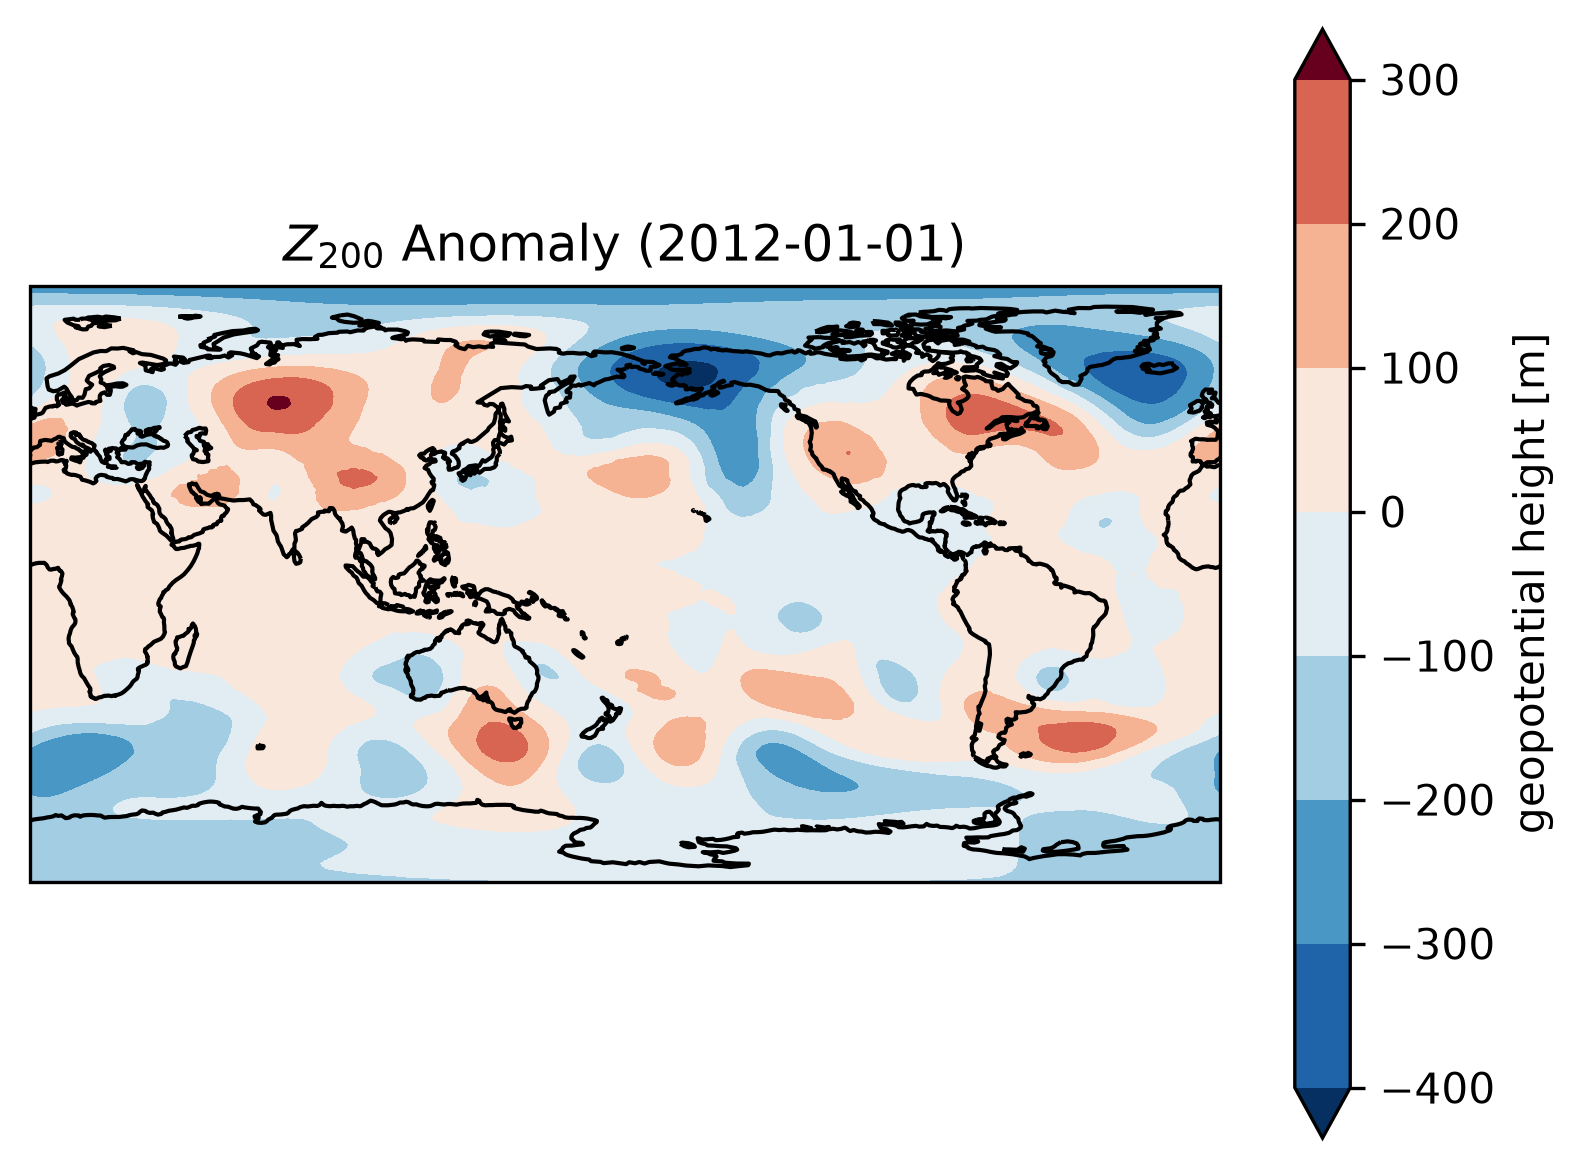

In [11]:
import matplotlib as mpl
from matplotlib import pyplot as plt
from cartopy import crs as ccrs   
mpl.rcParams['figure.dpi'] = 300

fig, ax = plt.subplots(1,1, 
                       subplot_kw=dict(projection=ccrs.PlateCarree(central_longitude=180)))                        
za200.sel(time='2012-01-01').plot.contourf(x='longitude', y='latitude', 
                        ax=ax, transform=ccrs.PlateCarree(), cmap='RdBu_r', extend='both')
ax.coastlines()
ax.set_title(r'$Z_{200}$ Anomaly (2012-01-01)')

**Example 1**: Plot the $Z_{200}$ regression maps on to RMM1 and RMM2. 

**Step 1**: Read MJO data from the IRI data library. 

In [12]:
import pandas as pd

# Read MJO data
mjo_ds = xr.open_dataset('http://iridl.ldeo.columbia.edu/SOURCES/.BoM/.MJO/.RMM/dods',
                         engine='netcdf4',
                         decode_times=False).rename({'T':'time'})
T = mjo_ds.time.values
mjo_ds['time'] = pd.date_range("1974-06-01", periods=len(T))  # The begining date of the RMM index is 1974-06-01
mjo_ds = mjo_ds.sel(time=za200.time).chunk({'time': 360})  # Align the time dimension of mjo_ds with za200
mjo_ds

HDF5-DIAG: Error detected in HDF5 (2.1.0) thread 2:
  #000: /home/conda/feedstock_root/build_artifacts/hdf5_1780922703635/work/src/H5F.c line 490 in H5Fis_accessible(): unable to determine if file is accessible as HDF5
    major: File accessibility
    minor: Not an HDF5 file
  #001: /home/conda/feedstock_root/build_artifacts/hdf5_1780922703635/work/src/H5VLcallback.c line 4109 in H5VL_file_specific(): file specific failed
    major: Virtual Object Layer
    minor: Can't operate on object
  #002: /home/conda/feedstock_root/build_artifacts/hdf5_1780922703635/work/src/H5VLcallback.c line 4045 in H5VL__file_specific(): file specific failed
    major: Virtual Object Layer
    minor: Can't operate on object
  #003: /home/conda/feedstock_root/build_artifacts/hdf5_1780922703635/work/src/H5VLnative_file.c line 344 in H5VL__native_file_specific(): error in HDF5 file check
    major: File accessibility
    minor: Can't get value
  #004: /home/conda/feedstock_root/build_artifacts/hdf5_17809227036

<xarray.Dataset> Size: 116kB
Dimensions:    (time: 3610)
Coordinates:
  * time       (time) datetime64[us] 29kB 1981-12-01 1981-12-02 ... 2021-02-28
    dayofyear  (time) int64 29kB dask.array<chunksize=(360,), meta=np.ndarray>
    level      int32 4B 200
Data variables:
    amplitude  (time) float32 14kB dask.array<chunksize=(360,), meta=np.ndarray>
    phase      (time) float32 14kB dask.array<chunksize=(360,), meta=np.ndarray>
    RMM1       (time) float32 14kB dask.array<chunksize=(360,), meta=np.ndarray>
    RMM2       (time) float32 14kB dask.array<chunksize=(360,), meta=np.ndarray>

**Step 2**: Calculate the regression coefficient $\mathbf{A}$ using the following equation:

$$\mathbf{A} = \dfrac{\mathrm{Cov}(X,Y)}{\mathrm{Cov}(X,X)}$$

where $X$ is predictor data (in this case, the RMM index), and $Y$ is predictand data (in this case, `za`).

In [13]:
z_rmm1_slope = xr.cov(za200, mjo_ds.RMM1, dim='time') / xr.cov(mjo_ds.RMM1, mjo_ds.RMM1, dim='time')
z_rmm2_slope = xr.cov(za200, mjo_ds.RMM2, dim='time') / xr.cov(mjo_ds.RMM2, mjo_ds.RMM2, dim='time')

syntax error, unexpected WORD_STRING, expecting ';' or ','
context: Attributes { T { String standard_name "time"; Float32 pointwidth 1.0; String calendar "standard"; Int32 expires 1784073600; Int32 gridtype 0; String units "julian_day"; } amplitude { Int32 expires 1784073600; String units "unitless"; Float32 missing_value 9.99999962E35; } phase { Int32 expires 1784073600; String units "unitless"; Float32 missing_value 999.0; } RMM1 { Int32 expires 1784073600; String units "unitless"; Float32 missing_value 9.99999962E35; } RMM2 { Int32 expires 1784073600; String units "unitless"; Float32 missing_value 9.99999962E35; }NC_GLOBAL { URL data source "http://www.bom.gov.au/climate/mjo/graphics/rmm.74toRealtime.txt"^; String Conventions "IRIDL"; String references "Wheeler_Hendon2004"; Int32 expires 1784073600; String description "Real-time Multivariate MJO Index (with components of interannual variability removed)"; URL Wheeler and Hendon (2004) Monthly Weather Review article "http://journals.

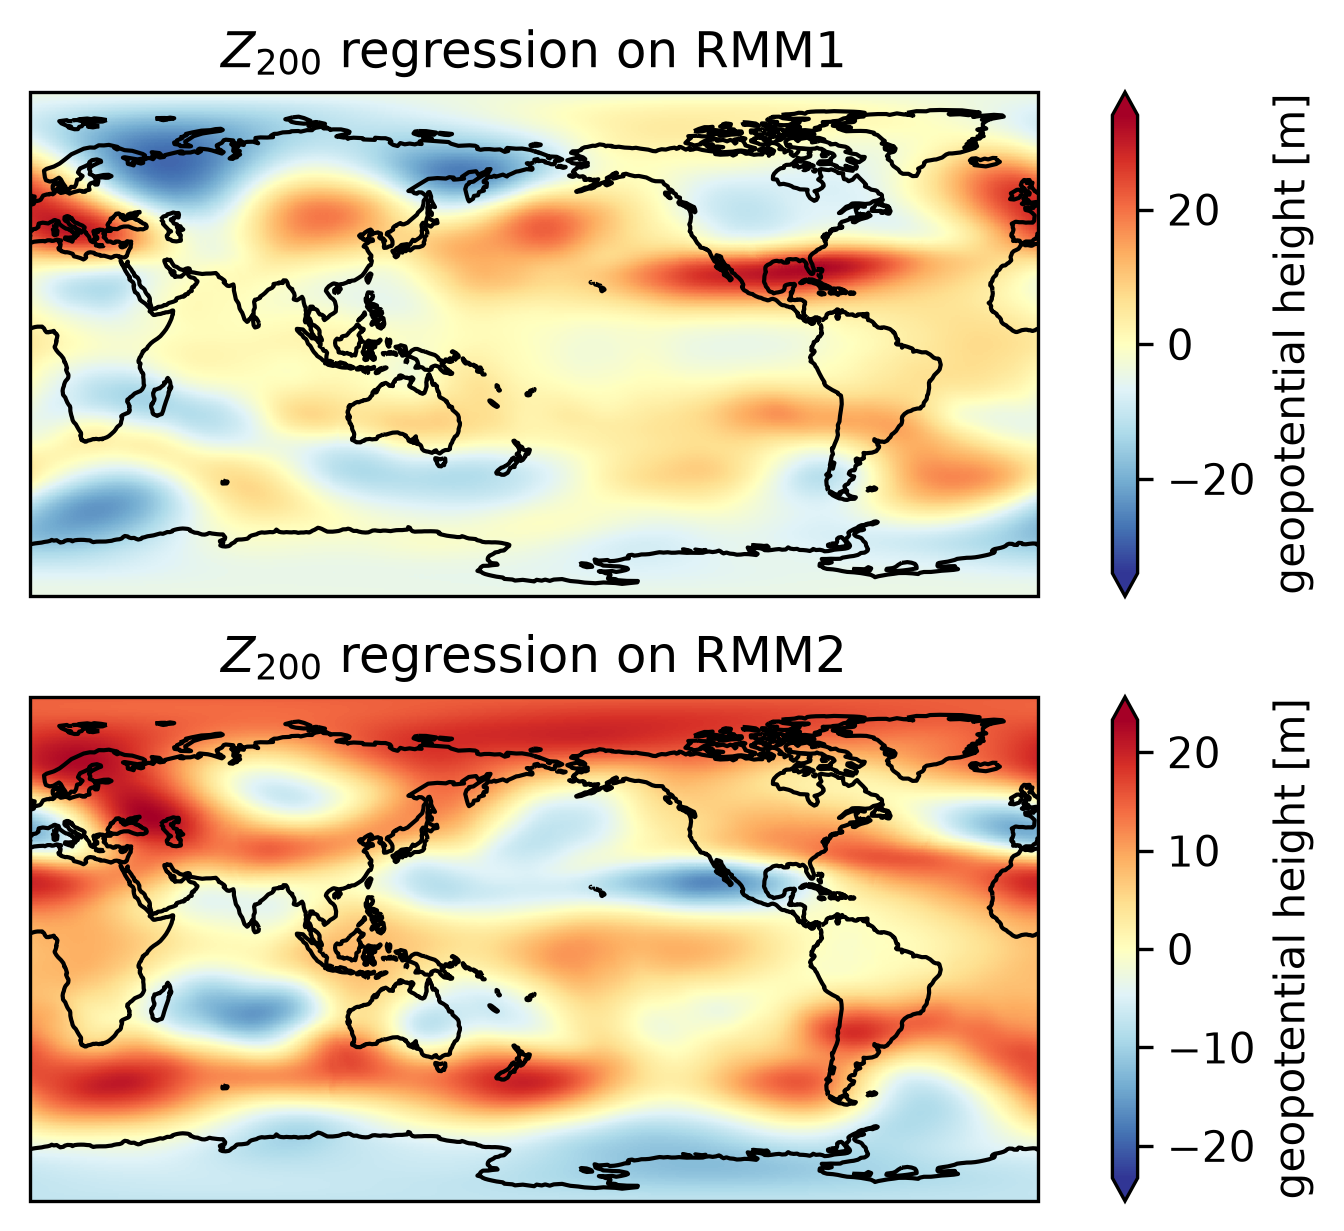

In [14]:
fig, ax = plt.subplots(2,1,
                       subplot_kw=dict(projection=ccrs.PlateCarree(central_longitude=180)))   

z_rmm1_slope.plot(x='longitude', y='latitude', ax=ax[0], cmap='RdYlBu_r', extend='both')
z_rmm2_slope.plot(x='longitude', y='latitude', ax=ax[1], cmap='RdYlBu_r', extend='both')

for i in range(2):
    ax[i].coastlines()
    ax[i].set_title(r'$Z_{200}$ regression on '+ f'RMM{i+1}')

### Takeaway

In this example, we practice the following workflow:
1. Open data lazily with Dask  
2. Decide chunking strategy  
3. Use `.persist()` for frequently reused core variables (`za200`) 
4. Use `.compute()` only when results are truly needed  

## Incorporating `flox` with `dask`

`flox` mainly provides strategies for fast `GroupBy` reductions with `dask.array`. 

**Example 2:** Calculate the composite mean of $Z_{200}$ for each MJO phase. 

In [15]:
from flox.xarray import xarray_reduce 

mjo_phase = mjo_ds.phase.compute()
mjo_amp = mjo_ds.amplitude.compute()
mjo_phase_sig = mjo_phase.where(mjo_amp >= 1, 0)  # Only consider the days when MJO amplitude is greater than 1

z200_mjo_comp = xarray_reduce(za200,
                              mjo_phase_sig, # Should be given explcitly, therefore we compute and load it.
                              func='mean',
                              dim='time',
                              isbin=False,
                              ) 
z200_mjo_comp = z200_mjo_comp.compute()
z200_mjo_comp 

syntax error, unexpected WORD_STRING, expecting ';' or ','syntax error, unexpected WORD_STRING, expecting ';' or ','

context: Attributes { T { String standard_name "time"; Float32 pointwidth 1.0; String calendar "standard"; Int32 expires 1784073600; Int32 gridtype 0; String units "julian_day"; } amplitude { Int32 expires 1784073600; String units "unitless"; Float32 missing_value 9.99999962E35; } phase { Int32 expires 1784073600; String units "unitless"; Float32 missing_value 999.0; } RMM1 { Int32 expires 1784073600; String units "unitless"; Float32 missing_value 9.99999962E35; } RMM2 { Int32 expires 1784073600; String units "unitless"; Float32 missing_value 9.99999962E35; }NC_GLOBAL { URL data source "http://www.bom.gov.au/climate/mjo/graphics/rmm.74toRealtime.txt"^; String Conventions "IRIDL"; String references "Wheeler_Hendon2004"; Int32 expires 1784073600; String description "Real-time Multivariate MJO Index (with components of interannual variability removed)"; URL Wheeler and Hen

<xarray.DataArray 'hgt' (phase: 9, latitude: 361, longitude: 720)> Size: 19MB
array([[[ -6.12425229,  -6.12425229,  -6.12425229, ...,  -6.12425229,
          -6.12425229,  -6.12425229],
        [ -6.5900867 ,  -6.58612001,  -6.58426549, ...,  -6.5969182 ,
          -6.59251816,  -6.5882107 ],
        [ -7.06218735,  -7.05693495,  -7.05503905, ...,  -7.07109191,
          -7.06594549,  -7.06352901],
        ...,
        [  3.94430518,   3.94811822,   3.95188974, ...,   3.93688368,
           3.93932545,   3.94294835],
        [  4.29463274,   4.29627064,   4.29755961, ...,   4.29307157,
           4.2947234 ,   4.29441844],
        [  4.66611303,   4.66611303,   4.66611303, ...,   4.66611303,
           4.66611303,   4.66611303]],

       [[-15.16923648, -15.16923648, -15.16923648, ..., -15.16923648,
         -15.16923648, -15.16923648],
        [-14.65104296, -14.65727839, -14.66664575, ..., -14.60842624,
         -14.62307881, -14.64020917],
        [-14.13128235, -14.18336393, -14.21370055, ..., -14.076148  ,
         -14.0901661 , -14.10748813],
...
        [-11.75934754, -11.76768372, -11.77246518, ..., -11.74105527,
         -11.74527806, -11.74994092],
        [-11.78523823, -11.78605494, -11.79438303, ..., -11.76520363,
         -11.76869274, -11.78031298],
        [-11.81079148, -11.81079148, -11.81079148, ..., -11.81079148,
         -11.81079148, -11.81079148]],

       [[ 25.26569139,  25.26569139,  25.26569139, ...,  25.26569139,
          25.26569139,  25.26569139],
        [ 24.08818567,  24.07650437,  24.0539886 , ...,  24.17420192,
          24.14588815,  24.1126576 ],
        [ 22.96400624,  22.93109731,  22.88577016, ...,  23.09010427,
          23.0545958 ,  22.9965963 ],
        ...,
        [  7.57654423,   7.58786073,   7.5972233 , ...,   7.54873719,
           7.55899447,   7.56315468],
        [  6.82745428,   6.84155737,   6.85050136, ...,   6.80765724,
           6.80915049,   6.81776613],
        [  6.09978123,   6.09978123,   6.09978123, ...,   6.09978123,
           6.09978123,   6.09978123]]], shape=(9, 361, 720))
Coordinates:
  * phase      (phase) float32 36B 0.0 1.0 2.0 3.0 4.0 5.0 6.0 7.0 8.0
  * latitude   (latitude) float32 1kB 90.0 89.5 89.0 88.5 ... -89.0 -89.5 -90.0
  * longitude  (longitude) float32 3kB 0.0 0.5 1.0 1.5 ... 358.5 359.0 359.5
    level      int32 4B 200
Attributes:
    standard_name:  geopotential_height
    long_name:      geopotential height
    units:          m

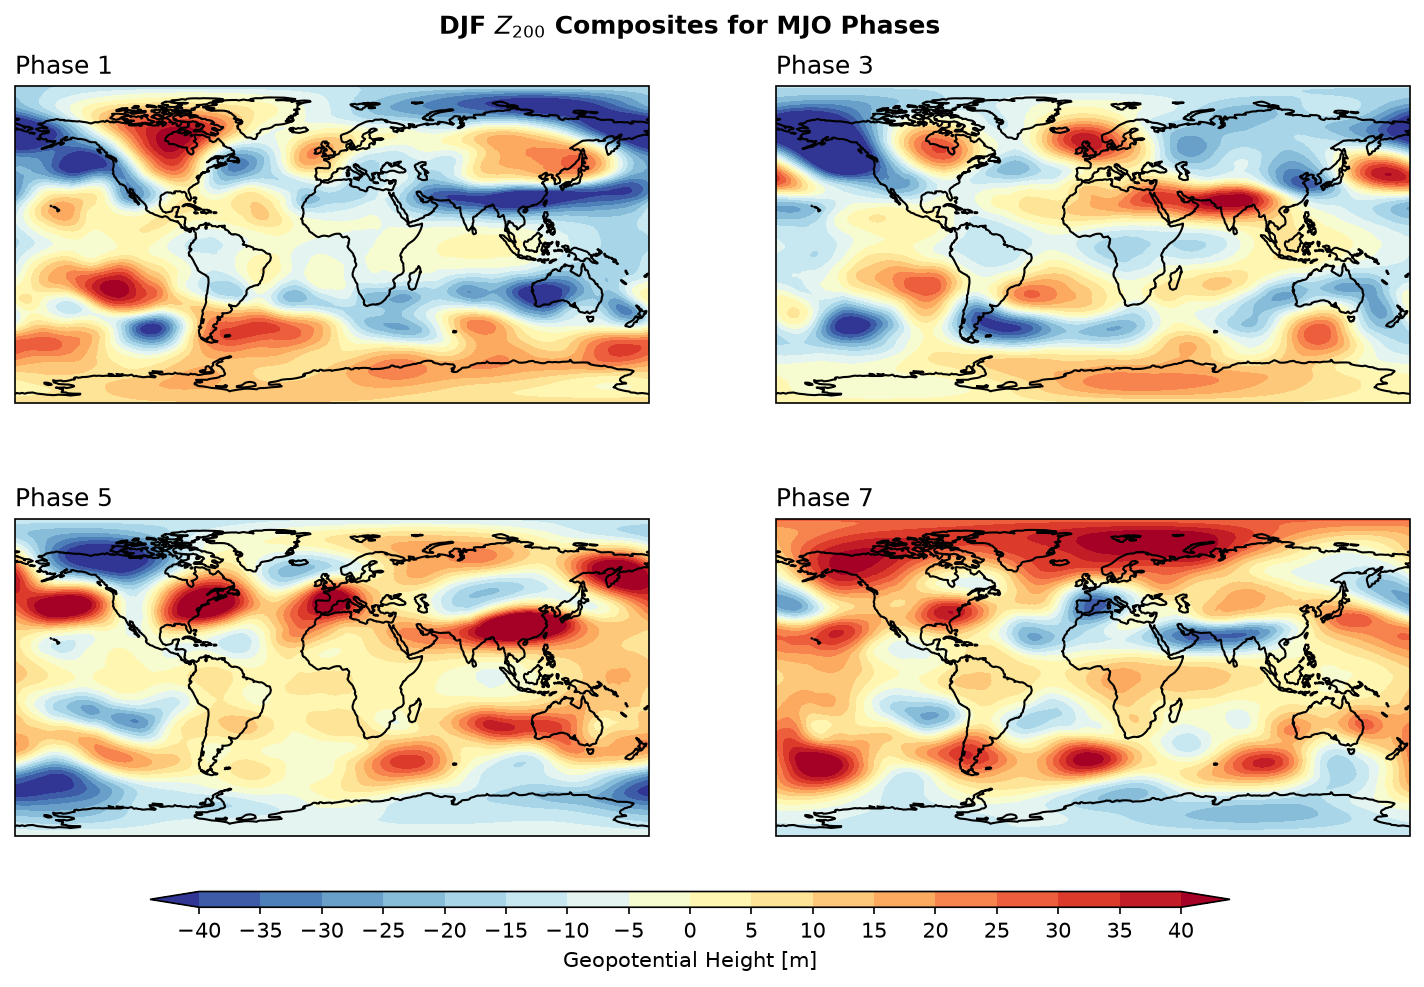

In [16]:
import matplotlib as mpl
from matplotlib import pyplot as plt
import cmaps
from cartopy import crs as ccrs   
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

mpl.rcParams['figure.dpi'] = 150

fig, axes = plt.subplots(2,2, 
                         subplot_kw={'projection': ccrs.PlateCarree()},
                         figsize=(12,7))
ax = axes.flatten()
lon_formatter = LONGITUDE_FORMATTER
lat_formatter = LATITUDE_FORMATTER

clevs = range(-40,45,5)

porder = [0,2,4,6,1,3,5,7]

for i in [1,3,5,7]: 
    cf = (z200_mjo_comp[i,:,:].plot.contourf(x='longitude',y='latitude', 
                                             ax=ax[int(i/2)],
                                             levels=clevs,
                                             add_colorbar=False,
                                             cmap='RdYlBu_r', 
                                             extend='both',
                                             transform=ccrs.PlateCarree()))
    
    ax[int(i/2)].coastlines()
    ax[int(i/2)].xaxis.set_major_formatter(lon_formatter)
    ax[int(i/2)].yaxis.set_major_formatter(lat_formatter)
    ax[int(i/2)].set_xlabel(' ')
    ax[int(i/2)].set_ylabel(' ')
    ax[int(i/2)].set_title(' ')
    ax[int(i/2)].set_title('Phase '+str(i), loc='left')
    
# Add a colorbar axis at the bottom of the graph
cbar_ax = fig.add_axes([0.2, 0.07, 0.6, 0.015])
# Draw the colorbar 將colorbar畫在cbar_ax這個軸上。
cbar = fig.colorbar(cf, cax=cbar_ax,
                    orientation='horizontal',
                    ticks=clevs,
                    label=r'Geopotential Height [m]')  

plt.subplots_adjust(hspace=0.15)
plt.suptitle('DJF $Z_{200}$ Composites for MJO Phases',y=0.92,size='large',weight='bold')
plt.show()    

## Loops with Parallel Computation

Some calculations cannot be directly expressed using intrinsic vectorized functions (like `xarray_reduce` from flox), because each iteration performs a separate, independent calculation rather than a single reduction that flox can express in one call. In these cases, we repeat the calculation across a loop instead.

Each iteration in such a loop is **independent** of the others, which means the iterations don't need to run in a fixed order. This independence is exactly what allows us to parallelize the loop with Dask.

Since the iterations are independent, we can parallelize the loop with Dask. The idea is:

1. Wrap the calculation for one iteration into a function.
2. Build a task for each iteration without executing it immediately.
3. Call `compute()` once, letting Dask schedule and run all the tasks in parallel across multiple workers.

Depending on whether the function operates on data that is already computed and loaded into RAM, or data that is still lazy, there are two different ways to build the computation task in step 2. If the data is already loaded into RAM, you can wrap the function as a delayed task (using `@delayed`), which returns a **Delayed object** representing that task. If the data is still lazy, you can write a normal function that returns lazy results directly, and only trigger the actual computation at the end with `compute()`. We will showcase both approaches using the following statistical test examples.

### The delayed task

The `@delayed` decorator before the function (`bootstrap_phase()` in the example below) is used to turn a normal Python function into a lazy task. Normally, when you call a function in Python, it executes immediately and returns a result. But with `@delayed`, the function call does **not** execute right away. Instead, it returns a **Delayed object** that represents a task in a computation graph.

The general structure is: 

```
@delayed
def function(x, i):
    ...... (Calculations needed, wrapped with a function) ...... 
    return results

tasks = [function(x, i) for i in range(n1,n2)]    # i is the iteration looped over 
results = compute(*tasks)   # tuple of xarray DataArrays, one per task

results_final = xr.concat(
                         results,
                         dim=xr.DataArray(list(range(n1, n2)), dims='concat_tim', name='concat_tim')
                     )  # Concatenate results into a single array
```

**Example 3:** Bootstrap Significance Test for MJO Phase Composites

We will demonstrate how to use the one-sample bootstrap, the simplest bootstrapping significance test, to estimate a confidence interval and perform a significance test. For each spatial point and each MJO phase, the null hypothesis is that the composite mean of the conditional population equals 0 (i.e., the climatology). To test the null hypothesis, we randomly resample data within the given MJO phase and calculate the composite mean. By repeating this resampling many times, the resampled composite means form a distribution.

The confidence interval is determined based on the resampled composite mean distribution. We first sort the resampled means. The lower and upper bounds of the 95% confidence interval are the 2.5th quantile and 97.5th quantile (i.e., the lowest 2.5% and the highest 2.5%). The null hypothesis is rejected when 0 falls outside this interval. In other words, the composite mean deviates from the climatology, in which case the composite is considered significant. You can find more details in Wilks (2019, pp. 185–187).

This method has been applied in other studies. Muhammad et al. (2020) used this method to test whether extreme precipitation composited across 8 MJO phases is significant relative to the climatology.

**Reference:**   
Muhammad, F. R., S. W. Lubis, S. Setiawan, 2020: Impacts of the Madden–Julian oscillation on precipitation extremes in Indonesia. *Int J Climatol.*, **41**, 1970–1984, https://doi.org/10.1002/joc.6941.  
Wilks, D.S., 2019 Statistical Methods in the Atmospheric Sciences. International Geophysics Series, 4th Edition, Elsevier, Amsterdam.  


In [17]:
@delayed
def bootstrap_significance_test(za_anom, mjo_phase, phase, nboot=100): # nboot=100 is only set for demonstration purpose. 
                                                           # In practice, nboot should be set to 1000 or more for better accuracy.
    data = za_anom.where(mjo_phase == phase, drop=True).compute()
    n = data.sizes['time']
    boot_mean = xr.concat([
        data.isel(time=np.random.randint(0, n, n)).mean('time')      # Randomly select n samples with replacement and compute the mean
        for _ in range(nboot)                                        # Repeat the above process nboot times to create a bootstrap distribution of means
    ], dim='bootstrap')
    q_result = boot_mean.quantile([0.025, 0.975], dim='bootstrap')   # Confidence interval: Compute the 2.5th and 97.5th percentiles of the bootstrap distribution
    sig_mask = (q_result.sel(quantile=0.025) > 0) | (q_result.sel(quantile=0.975) < 0) # Significant mask: True if the 95% confidence interval does not include zero
    return sig_mask

tasks = [bootstrap_significance_test(za200, mjo_phase_sig, p) for p in range(0, 9)]
sig_masks = compute(*tasks)

sig_masks_combined = xr.concat(
    sig_masks,
    dim=xr.DataArray(np.arange(0, 9), dims='phase', name='phase')
)
sig_masks_combined

<xarray.DataArray 'hgt' (phase: 9, latitude: 361, longitude: 720)> Size: 2MB
array([[[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],

       [[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],

       [[ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        ...,
...
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True]],

       [[ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        ...,
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True]],

       [[ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]]],
      shape=(9, 361, 720))
Coordinates:
  * phase      (phase) int64 72B 0 1 2 3 4 5 6 7 8
  * latitude   (latitude) float32 1kB 90.0 89.5 89.0 88.5 ... -89.0 -89.5 -90.0
  * longitude  (longitude) float32 3kB 0.0 0.5 1.0 1.5 ... 358.5 359.0 359.5
Attributes:
    standard_name:  geopotential_height
    long_name:      geopotential height
    units:          m

```{note}
After we subset the MJO phase data, we compute and load the array to RAM.

`data = za_anom.where(mjo_phase == phase, drop=True).compute()`

Why do we do this? 

Inside the loop, we resample the data `nboot` times, each time selecting a different, randomly-repeated set of time indices via `np.random.randint`. If `data` were still a lazy dask array, each of these random resampling operations would build a separate, independent branch of the task graph. Since the indices differ every time, dask cannot share or simplify computation across iterations. Repeating this hundreds of times would cause the number of graph layers to grow rapidly, making graph construction itself a major bottleneck. By calling `.compute()` once here, we convert the phase's subset into an in-memory NumPy array, so the repeated resampling afterward is plain NumPy indexing with no graph-building overhead.

A secondary consideration: if the boolean mask itself were still lazy, dask may not know the resulting size along the time dimension until it is computed. In that case, `n = data.sizes['time']` could return nan instead of a concrete integer, which would break the resampling step below.
```

Finally, we overlay the significance mask on the composite plots. The significance mask is a boolean array where True indicates that the composite mean is significantly different from zero at the 95% confidence level.

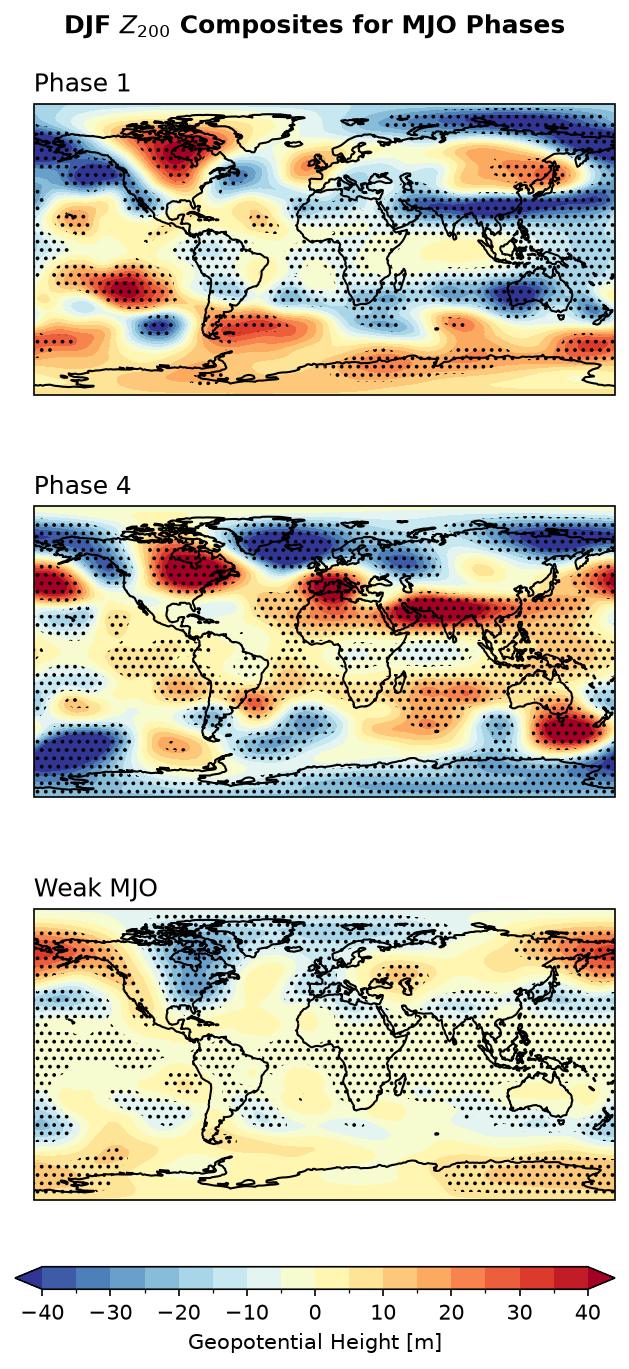

In [18]:
fig, axes = plt.subplots(3,1, 
                         subplot_kw={'projection': ccrs.PlateCarree()},
                         figsize=(5,10))
ax = axes.flatten()
lon_formatter = LONGITUDE_FORMATTER
lat_formatter = LATITUDE_FORMATTER

clevs = range(-40,45,5)

porder = [0,2,4,6,1,3,5,7]

sig_int = sig_masks_combined.astype(int)

title_string = ['Phase 1', 'Phase 4', 'Weak MJO']

j=0
for i in [1,4,0]: 
    cf = (z200_mjo_comp[i,:,:].plot.contourf(x='longitude',y='latitude', 
                                             ax=ax[j],
                                             levels=clevs,
                                             add_colorbar=False,
                                             cmap='RdYlBu_r', 
                                             extend='both',
                                             transform=ccrs.PlateCarree()))
    
    sig_hatch = sig_int[i,:,:].plot.contourf(ax=ax[j],
                                             levels=[0, 0.5, 1],       # 只切成「不顯著(0)」跟「顯著(1)」兩帶
                                             colors='none',            # 不要填色,只保留線框/hatch
                                             hatches=['', '...'],      # 不顯著:空白;顯著:打點
                                             add_colorbar=False,
                                         )
    ax[j].coastlines()
    ax[j].xaxis.set_major_formatter(lon_formatter)
    ax[j].yaxis.set_major_formatter(lat_formatter)
    ax[j].set_xlabel(' ')
    ax[j].set_ylabel(' ')
    ax[j].set_title(' ')
    ax[j].set_title(title_string[j], loc='left')
    j = j + 1
    
# Add a colorbar axis at the bottom of the graph
cbar_ax = fig.add_axes([0.1, 0.07, 0.8, 0.015])
# Draw the colorbar 將colorbar畫在cbar_ax這個軸上。
cbar = fig.colorbar(cf, cax=cbar_ax,
                    orientation='horizontal',
                    ticks=range(-40,50,10),
                    label=r'Geopotential Height [m]')  

plt.subplots_adjust(hspace=0.15)
plt.suptitle('DJF $Z_{200}$ Composites for MJO Phases',y=0.92,size='large',weight='bold')
plt.show()    

### Building the task without `@delayed`

When the data and its operation inside (e.g., `.isel()`, `.mean()`, `.quantile()`) are already lazy, we don't wrap the function with `@delayed`. Because Dask already understands these operations, calling the function does not require `@delayed` at all: the function call itself returns a lazy xarray object, already built from Dask's own task graph.

The overall workflow is otherwise the same as before: calling the function once for each of the 8 phases builds 8 independent lazy objects (This will be very quick since nothing is computed yet) and calling `compute()` on all of them together is still what triggers Dask to build the full task graph and schedule the work across multiple workers in parallel.

**Example 4:** Here we demonstrate another type of significance test.

The null hypothesis is that the composite mean of the given MJO phase has no difference from the climatology. To test the hypothesis, we randomly draw the same number of days as observed in that MJO phase from the full record (regardless of phase), and compute a composite mean. Repeating this n_boot times forms a null distribution. To reject the null hypothesis, the composite mean of the given MJO phase should fall outside the middle 95% of the null distribution, or should be lower than the 2.5th percentile or higher than the 97.5th percentile. See more details in Wilks (2019, pp. 182-185). This method is the same as Matthews and Kiladis (1999, see Appendix), where they test the local significance of the variable differences between the strong and weak jet winters. 

**References:**  
Matthews, A. J., and G. N. Kiladis, 1999: Interactions between ENSO, Transient Circulation, and Tropical Convection over the Pacific. *J. Climate*, **12**, 3062–3086, [https://doi.org/10.1175/1520-0442(1999)012<3062:IBETCA>2.0.CO;2](https://doi.org/10.1175/1520-0442(1999)012<3062:IBETCA>2.0.CO;2).    
Wilks, D.S., 2019 Statistical Methods in the Atmospheric Sciences. International Geophysics Series, 4th Edition, Elsevier, Amsterdam. 

In [19]:
za200_rechunked = za200.chunk({'time': -1, 'latitude': 91, 'longitude': 120}).persist()
za200_rechunked

<xarray.DataArray 'hgt' (time: 3610, latitude: 361, longitude: 720)> Size: 8GB
dask.array<rechunk-merge, shape=(3610, 361, 720), dtype=float64, chunksize=(3610, 91, 120), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 29kB 1981-12-01 1981-12-02 ... 2021-02-28
    dayofyear  (time) int64 29kB dask.array<chunksize=(3610,), meta=np.ndarray>
  * latitude   (latitude) float32 1kB 90.0 89.5 89.0 88.5 ... -89.0 -89.5 -90.0
  * longitude  (longitude) float32 3kB 0.0 0.5 1.0 1.5 ... 358.5 359.0 359.5
    level      int32 4B 200
Attributes:
    standard_name:  geopotential_height
    long_name:      geopotential height
    units:          m

In [20]:
n_total = za200_rechunked.sizes['time']

def permutation_significance_test(za, mjo_phase, phase, nboot=100):
    obs_mask = (mjo_phase == phase)
    obs_composite = za.where(obs_mask, drop=True).mean('time')
    n_p = int(obs_mask.sum())       # Number of samples in the observed composite (used in the permutation test)

    idx_matrix = np.stack([
        np.random.choice(n_total, n_p, replace=False)
        for _ in range(nboot)      # Repeat the above process nboot times to create a bootstrap distribution of means
    ])
    idx_da = xr.DataArray(idx_matrix, dims=['bootstrap', 'time'])
    null_means = za.isel(time=idx_da).mean('time')     # Compute the mean of the randomly selected samples for each bootstrap iteration

    q_result = null_means.quantile([0.025, 0.975], dim='bootstrap')    # Compute the 2.5th and 97.5th percentiles of the null distribution 
                                                                       # to form a confidence interval
    return (obs_composite > q_result.sel(quantile=0.975)) | (obs_composite < q_result.sel(quantile=0.025)) 
            # Significant mask: significant if the composite mean is outside the 95% confidence interval of the null distribution

# To build up the dask graph (No need to add @delayed)
sig_masks_lazy = [permutation_significance_test(za200_rechunked, mjo_phase_sig, p) for p in range(0, 9)]
sig_masks = compute(*sig_masks_lazy)

sig_masks_combined = xr.concat(
    sig_masks,
    dim=xr.DataArray(np.arange(0, 9), dims='phase', name='phase')
)
sig_masks_combined

/data/wtsai/micromamba/p312/lib/python3.12/site-packages/distributed/client.py:3415: UserWarning: Sending large graph of size 35.30 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


<xarray.DataArray 'hgt' (phase: 9, latitude: 361, longitude: 720)> Size: 2MB
array([[[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [ True,  True,  True, ...,  True,  True,  True],
        ...,
        [False, False, False, ..., False, False, False],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True]],

       [[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],

       [[ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        ...,
...
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True]],

       [[ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        ...,
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True]],

       [[ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]]],
      shape=(9, 361, 720))
Coordinates:
  * phase      (phase) int64 72B 0 1 2 3 4 5 6 7 8
  * latitude   (latitude) float32 1kB 90.0 89.5 89.0 88.5 ... -89.0 -89.5 -90.0
  * longitude  (longitude) float32 3kB 0.0 0.5 1.0 1.5 ... 358.5 359.0 359.5
    level      int32 4B 200
Attributes:
    standard_name:  geopotential_height
    long_name:      geopotential height
    units:          m

```{note}
**Why rechunk and persist first?** 

Because these indices are scattered randomly across the whole time range rather than falling in one contiguous block, Dask has to figure out, for every single selected day, which chunk it belongs to. If the `time` dimension is split into many chunks, this lookup has to happen many times over, and the resulting task graph grows very large — even though the underlying data was already computed and persisted.

To avoid this, we rechunk `za200` so that `time` is kept as a single chunk, and instead split the `latitude`/`longitude` dimensions into smaller pieces. This works because the random sampling and the `mean('time')` reduction only ever operate along `time` — there's no need to split that dimension into chunks, since every draw has to look across the whole time range anyway. `latitude` and `longitude`, on the other hand, are independent of each other and of the sampling process.
```

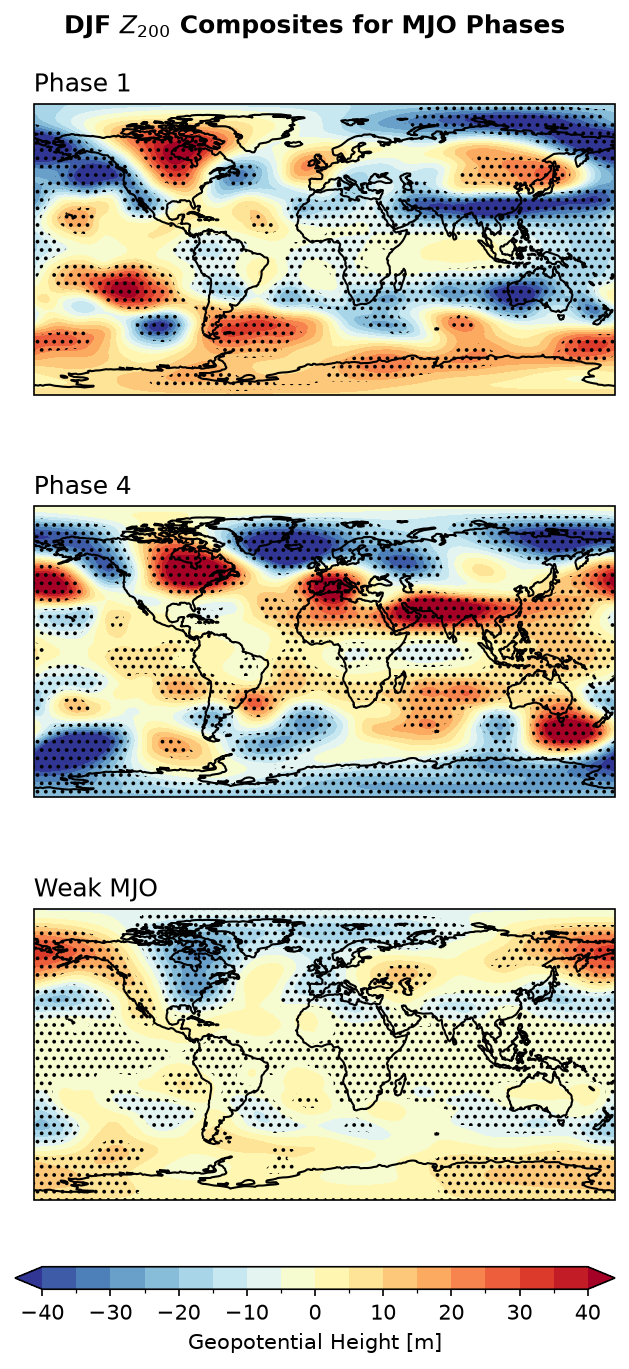

In [21]:
fig, axes = plt.subplots(3,1, 
                         subplot_kw={'projection': ccrs.PlateCarree()},
                         figsize=(5,10))
ax = axes.flatten()
lon_formatter = LONGITUDE_FORMATTER
lat_formatter = LATITUDE_FORMATTER

clevs = range(-40,45,5)

porder = [0,2,4,6,1,3,5,7]

sig_int = sig_masks_combined.astype(int)

title_string = ['Phase 1', 'Phase 4', 'Weak MJO']

j=0
for i in [1,4,0]: 
    cf = (z200_mjo_comp[i,:,:].plot.contourf(x='longitude',y='latitude', 
                                             ax=ax[j],
                                             levels=clevs,
                                             add_colorbar=False,
                                             cmap='RdYlBu_r', 
                                             extend='both',
                                             transform=ccrs.PlateCarree()))
    
    sig_hatch = sig_int[i,:,:].plot.contourf(ax=ax[j],
                                             levels=[0, 0.5, 1],       # 只切成「不顯著(0)」跟「顯著(1)」兩帶
                                             colors='none',            # 不要填色,只保留線框/hatch
                                             hatches=['', '...'],      # 不顯著:空白;顯著:打點
                                             add_colorbar=False,
                                         )
    ax[j].coastlines()
    ax[j].xaxis.set_major_formatter(lon_formatter)
    ax[j].yaxis.set_major_formatter(lat_formatter)
    ax[j].set_xlabel(' ')
    ax[j].set_ylabel(' ')
    ax[j].set_title(' ')
    ax[j].set_title(title_string[j], loc='left')
    j = j + 1
    
# Add a colorbar axis at the bottom of the graph
cbar_ax = fig.add_axes([0.1, 0.07, 0.8, 0.015])
# Draw the colorbar 將colorbar畫在cbar_ax這個軸上。
cbar = fig.colorbar(cf, cax=cbar_ax,
                    orientation='horizontal',
                    ticks=range(-40,50,10),
                    label=r'Geopotential Height [m]')  

plt.subplots_adjust(hspace=0.15)
plt.suptitle('DJF $Z_{200}$ Composites for MJO Phases',y=0.92,size='large',weight='bold')
plt.show()    

### Key Takeaway

In this section, we introduced how to parallelize a loop with Dask: build one task per iteration, then call `compute()` once to let Dask schedule and run them across multiple workers. Whether a task needs `@delayed` depends on what the function does internally. If the function operates on data that has already been computed and loaded into memory, wrap it with `@delayed`. If the function is built entirely from lazy Dask/xarray operations, skip `@delayed`. Dask's own [delayed best practices](https://docs.dask.org/en/latest/delayed-best-practices.html) recommend against wrapping such a function in `@delayed`, since passing a Dask array into a `@delayed` call forces Dask to treat the whole function as one opaque task, hiding its internal structure from the scheduler and preventing it from optimizing work across calls.

## Summary: When to use Dask? 

**Use Dask:**. 

- When you have large datasets that don’t fit into memory on a single machine.  

- When you need to perform parallel computations, such as big data analysis.  

**Avoid Dask:**

- When you have small datasets that can be processed efficiently on a single machine.

- When you don’t need parallel processing, as the overhead of managing a distributed computing environment may not be worth the benefits.

- When you need to debug or troubleshoot problems, as distributed computing environments can be challenging for debugging. If the problem is complex, using Dask may make debugging more difficult.

Learn more about [best practices with Dask](https://docs.dask.org/en/stable/best-practices.html).

## Closing Dask Cluster and Clients

In [22]:
client.close()
cluster.close()